# CIFAR-10 Fully Connected Network (FCN) Implementation

This document contains the implementation of a Fully Connected Network (FCN) for classifying images from the CIFAR-10 dataset. The CIFAR-10 dataset consists of 60,000 32x32 color images in 10 classes, with 6,000 images per class. The FCN architecture will be designed to process the flattened pixel values of the images and output class probabilities.

In [28]:
import warnings
# Suppress NumPy 2.4 deprecation warning from Keras pickle loading
warnings.filterwarnings("ignore", message=".*align should be passed as Python or NumPy boolean.*")

In [29]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"
import keras
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import cifar10
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from keras import layers, regularizers, Model, Input
from keras.optimizers import Adam

# Load and preprocess the CIFAR-10 dataset
The dataset is loaded by using cifar10.load_data(), which returns the training and test sets. The images are normalized to have pixel values between 0 and 1, and the class labels are converted to one-hot encoded vectors for use in the model.
The cifar10 dataset consists of 10 classes:
- airplane
- automobile
- bird
- cat
- deer
- dog
- frog
- horse
- ship
- truck

The training set contains 50,000 images, while the test set contains 10,000 images. Each image is a 32x32 pixel color image with 3 channels (RGB).


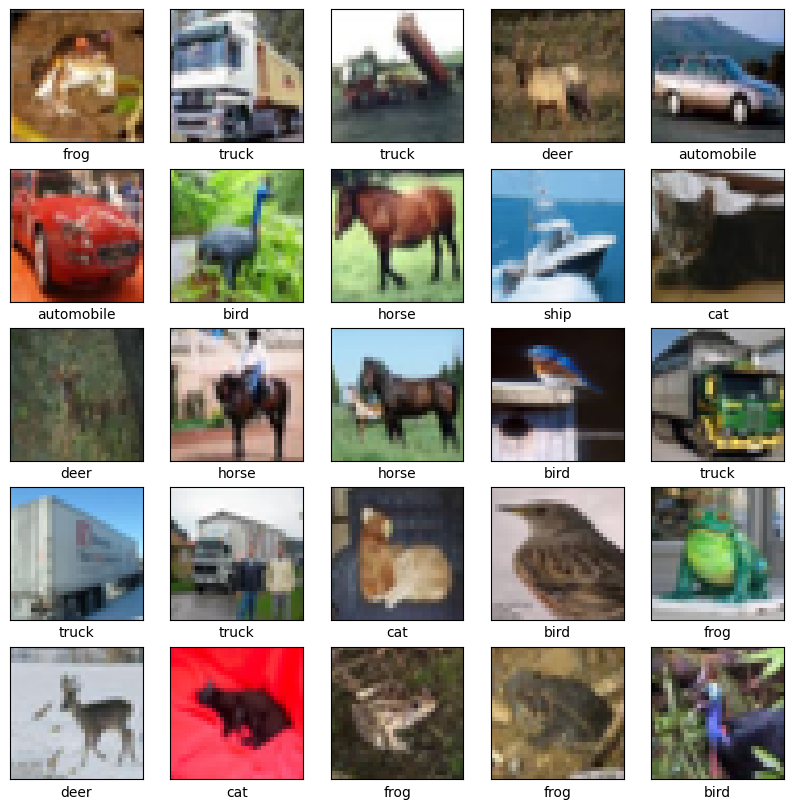

In [30]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.xlabel(class_names[y_train[i][0]])
plt.show()

# Preparing the data
Scale the pixel values to be between 0 and 1 by dividing by 255.0. Also, convert the class labels to one-hot encoded vectors. The input shape of the images is (32, 32, 3) since they are 32x32 pixels with 3 color channels (RGB). The number of classes is 10, corresponding to the 10 different categories in the CIFAR-10 dataset.

In [31]:
# Define the number of classes in the dataset
num_classes = 10
# Define the input shape of the images
input_shape = (32, 32, 3)

# Normalize pixel values to be between 0 and 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Convert class vectors to binary class matrices (one-hot encoding)
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

# Print the shapes of the training and test sets
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 10)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 10)


# Build the Fully Connected Network (FCN) model.
The architecture consists of a Flatten layer to convert the 3D image data into a 1D vector, followed by several Dense layers with ReLU activation and L2 regularization to prevent overfitting. Batch normalization is applied after each Dense layer to stabilize and accelerate training, and Dropout layers are included to further reduce overfitting. The final output layer uses a softmax activation function to produce class probabilities for the 10 classes.

Neurons used:
- First Dense layer: 1024 neurons
- Second Dense layer: 512 neurons
- Third Dense layer: 256 neurons
- Output Dense layer: 10 neurons (one for each class)



In [32]:
inputs = Input(shape=input_shape)
x = layers.Flatten()(inputs)
x = layers.Dense(1024, kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(512, kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,812,618 (14.54 MB)

 Trainable params: 3,809,034 (14.53 MB)

 Non-trainable params: 3,584 (14.00 KB)

Total parameters is 3,812,618 which is significantly higher than the CNN model we built, which had 309,290 parameters. This is because the FCN architecture does not take advantage of the spatial structure of the images, leading to a large number of parameters in the fully connected layers. In contrast, CNNs use convolutional layers that share weights and reduce the number of parameters while still capturing important features from the images.

Total trainable parameters is 3,809,034 which is also significantly higher than the CNN model, which had 308,394 trainable parameters. The large number of trainable parameters in the FCN can lead to overfitting, especially if the dataset is not sufficiently large or if regularization techniques are not properly applied. In contrast, CNNs typically have fewer trainable parameters due to weight sharing in convolutional layers, which helps to mitigate overfitting and improve generalization to unseen data.

Non-trainable parameters is 3,548 which is also higher than the CNN model, which had 896 non-trainable parameters. Non-trainable parameters typically include parameters from layers such as Batch Normalization, which have moving averages of mean and variance that are not updated during backpropagation. The higher number of non-trainable parameters in the FCN is likely due to the larger number of Batch Normalization layers used in the architecture compared to the CNN model.

# Compile the model
The model is compiled using the Adam optimizer, which is an efficient optimization algorithm that adjusts the learning rate during training. The loss function used is categorical crossentropy, which is appropriate for multi-class classification problems. The metric for evaluation during training and testing is accuracy, which measures the proportion of correctly classified samples.

In [33]:
model.compile(optimizer=Adam(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
The model is trained for 20 epochs with a batch size of 64. A validation split of 0.2 is used to evaluate the model's performance on unseen data during training. Two callbacks are defined: ReduceLROnPlateau, which reduces the learning rate when the validation loss plateaus, and EarlyStopping, which stops training if the validation loss does not improve for a specified number of epochs and restores the best weights.

In [34]:
# Define callbacks
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(x_train, y_train,
                    epochs=20,
                    batch_size=64,
                    validation_split=0.2,
                    callbacks=[reduce_lr, early_stopping])

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.3532 - loss: 2.1006 - val_accuracy: 0.3619 - val_loss: 2.0445 - learning_rate: 0.0010
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4340 - loss: 1.8499 - val_accuracy: 0.3178 - val_loss: 2.1995 - learning_rate: 0.0010
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4549 - loss: 1.7739 - val_accuracy: 0.3935 - val_loss: 1.9773 - learning_rate: 0.0010
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4710 - loss: 1.7301 - val_accuracy: 0.3081 - val_loss: 2.4361 - learning_rate: 0.0010
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4789 - loss: 1.7163 - val_accuracy: 0.4199 - val_loss: 1.9530 - learning_rate: 0.0010
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4837 - loss: 1.7079 - val_accuracy: 0.3287 - val_loss: 2.1667 - learning_rate: 0.0010
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4926 - loss: 1.6940 - 

# Evaluate the model
The model's performance is evaluated by plotting the training and validation loss and accuracy over the epochs. This visualization helps to understand how well the model is learning and whether it is overfitting or underfitting. Finally, the model is evaluated on the test set to obtain the final test accuracy and loss, which indicates how well the model generalizes to unseen data.

Comparing FCN to CNN, the CNN is expected to perform better on image classification tasks like CIFAR-10 due to its ability to capture spatial hierarchies and local patterns in the images, while the FCN treats the input as a flat vector, losing spatial information. However, the FCN can still achieve reasonable performance with proper regularization and architecture design.



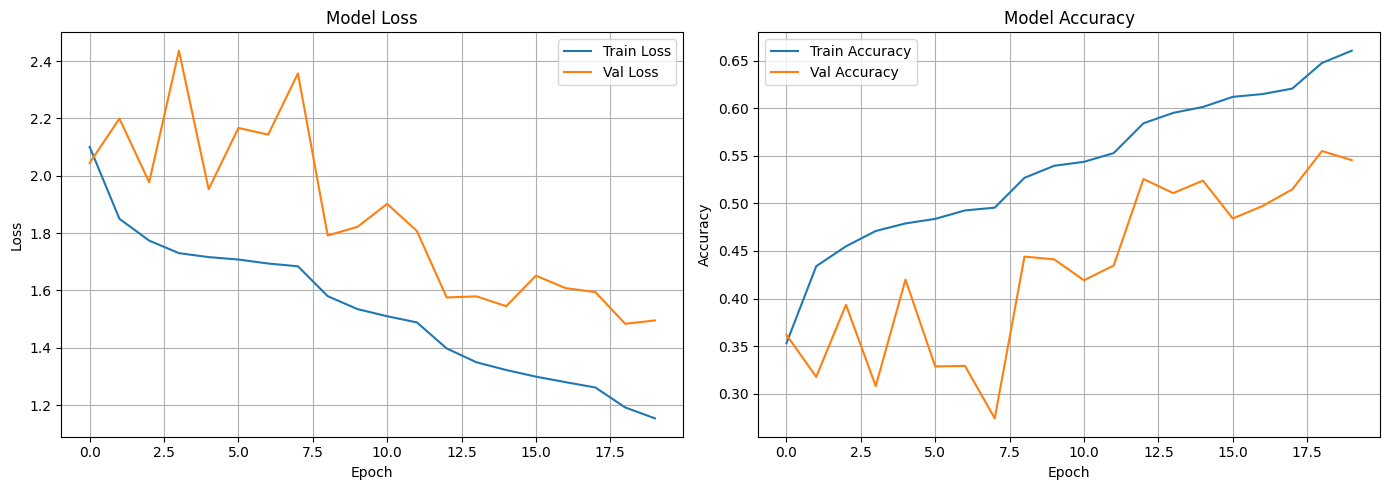

313/313 - 1s - 4ms/step - accuracy: 0.5530 - loss: 1.4706

Test accuracy: 0.5530
Test loss: 1.4706


In [35]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axs[0].plot(history.history["loss"], label="Train Loss")
axs[0].plot(history.history["val_loss"], label="Val Loss")
axs[0].set_title("Model Loss")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].legend()
axs[0].grid(True)

# Accuracy plot
axs[1].plot(history.history["accuracy"], label="Train Accuracy")
axs[1].plot(history.history["val_accuracy"], label="Val Accuracy")
axs[1].set_title("Model Accuracy")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Accuracy")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

# Evaluate and print test results
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

# Visualize the predictions of the model on a few test images.
The visualization will show the original image along with a bar chart of the predicted class probabilities for each of the 10 classes.
This way its easier to understand how the model is making its predictions and which classes it is most confident about for each image. The class names are displayed on the x-axis of the bar chart for better readability.

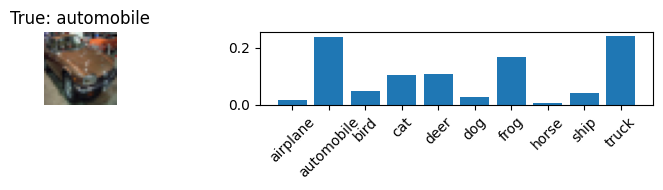

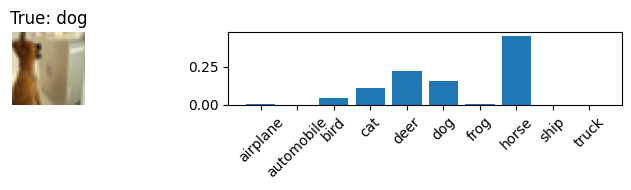

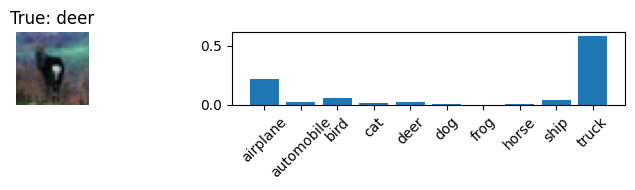

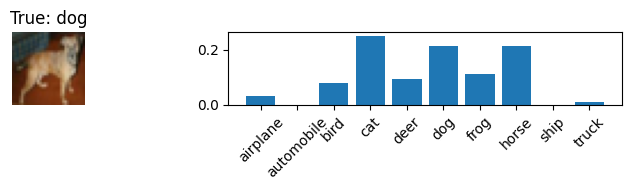

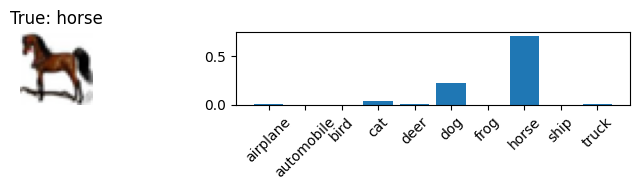

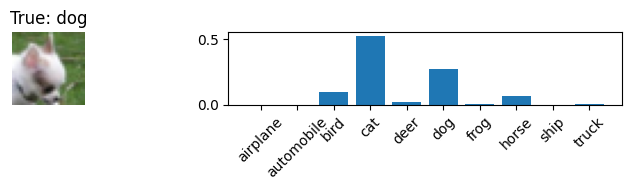

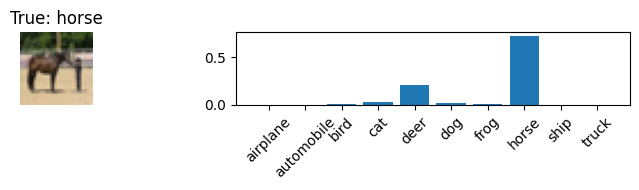

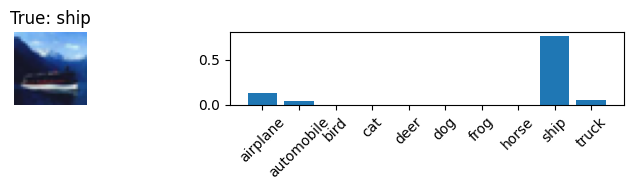

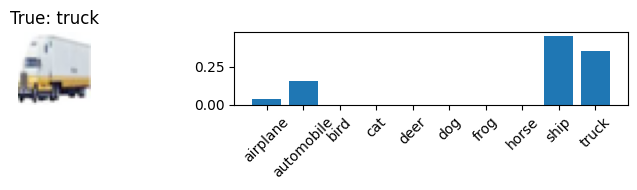

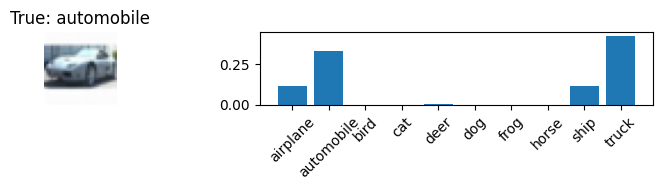

In [36]:
x = x_test
y = model(x)
start = 2000

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

for k in range(10):
    plt.figure(figsize=(8, 2))
    plt.subplot(1, 2, 1)
    plt.title(f"True: {class_names[np.argmax(y_test[start+k])]}")
    plt.imshow(x[start + k].reshape((32, 32, 3)))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    ind = np.arange(10)
    plt.bar(ind, y[start + k].numpy().flatten())

    plt.xticks(ind, class_names, rotation=45)
    plt.tight_layout()
    plt.show()